In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
def imshow(image= None):
  """
  Display a BGR image using Matplotlib.

  Converts the input image from OpenCV's BGR color space to RGB
  before displaying it and hides the axis for cleaner visualization.
  """
  plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
  plt.axis("off")
  plt.show()

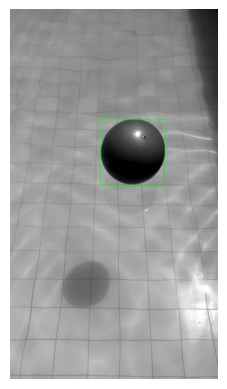

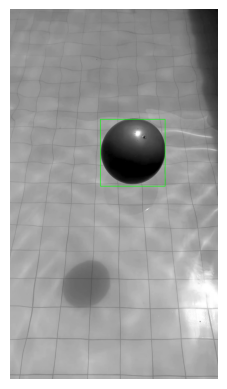

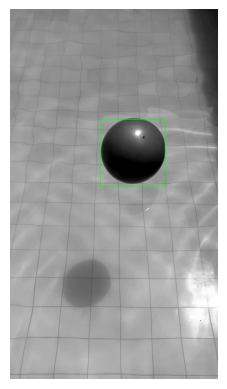

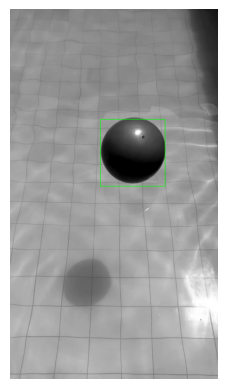

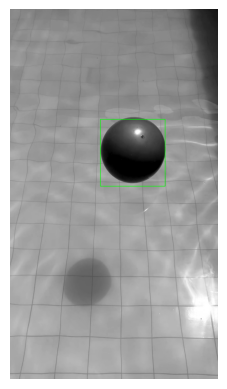

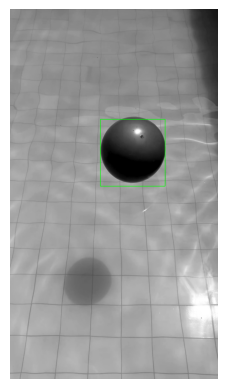

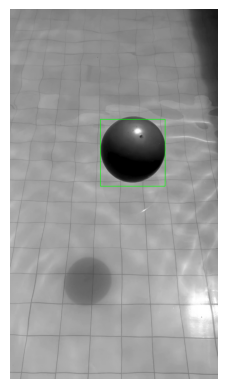

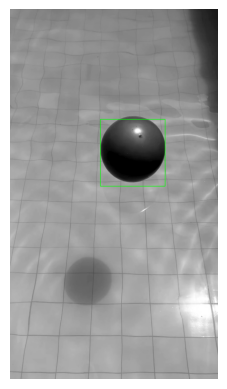

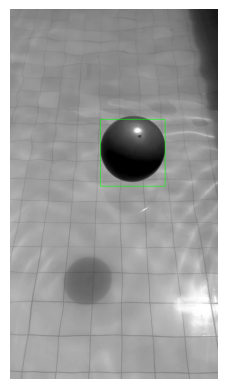

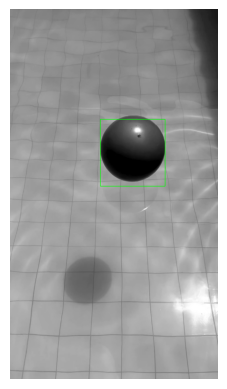

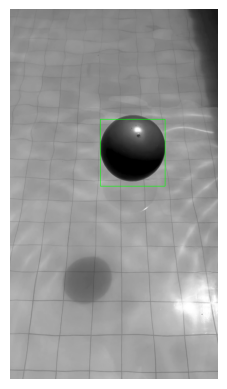

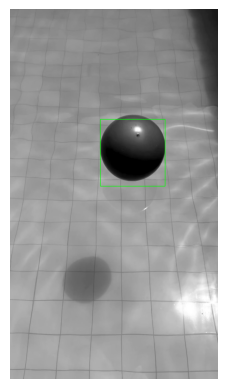

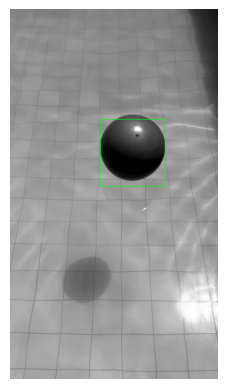

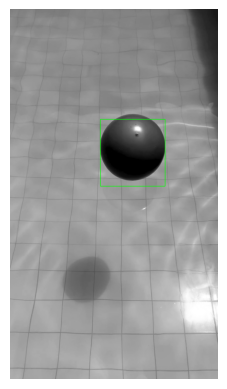

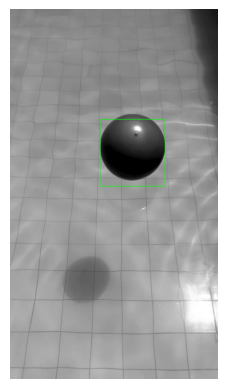

In [7]:
# Open video file
cap = cv.VideoCapture("/content/drive/MyDrive/ball.mp4")

# Read first frame
ret, frame = cap.read()

if ret:

    # Convert first frame to grayscale
    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

    # Detect edges
    edged = cv.Canny(gray, 50, 200)

    # Find contours
    contours, hierarchy = cv.findContours(
        edged,
        cv.RETR_EXTERNAL,
        cv.CHAIN_APPROX_NONE
    )

    # Sort contours by area (largest first)
    sorted_contour = sorted(
        contours,
        key=cv.contourArea,
        reverse=True
    )

    # Assume largest contour is the target object
    contour = sorted_contour[0]

    # Approximate contour shape
    approx = cv.approxPolyDP(
        contour,
        0.03 * cv.arcLength(contour, True),
        True
    )

    # Check shape condition
    if len(approx) >= 7:

        # Create initial tracking window
        x, y, w, h = cv.boundingRect(contour)
        track_window = (x, y, w, h)

        # Extract ROI from first frame
        roi = frame[y:y+h, x:x+w]

        # Convert ROI to HSV color space
        roi_hsv = cv.cvtColor(
            roi,
            cv.COLOR_BGR2HSV
        )

        # Remove low-saturation and dark pixels
        mask = cv.inRange(
            roi_hsv,
            np.array((0., 60., 32.)),
            np.array((180., 255., 255.))
        )

        # Compute Hue histogram of ROI
        hist_roi = cv.calcHist(
            [roi_hsv],
            [0],
            mask,
            [180],
            [0, 180]
        ).astype(np.float32)

        # Normalize histogram
        cv.normalize(
            hist_roi,
            hist_roi,
            0,
            255,
            cv.NORM_MINMAX
        )

        # MeanShift termination criteria
        crit = (
            cv.TERM_CRITERIA_EPS |
            cv.TERM_CRITERIA_COUNT,
            10,
            1
        )

        # Process next frames
        for i in range(15):

            ret, frame = cap.read()

            if frame is None:
                break

            # Convert current frame to HSV
            hsv = cv.cvtColor(
                frame,
                cv.COLOR_BGR2HSV
            )

            # Generate probability map using histogram back projection
            dst = cv.calcBackProject(
                [hsv],
                [0],
                hist_roi,
                [0, 180],
                1
            )

            # Apply MeanShift tracking
            _, track_window = cv.meanShift(
                dst,
                track_window,
                crit
            )

            # Get updated window position
            x, y, w, h = track_window

            # Draw tracking window
            cv.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            # Display tracking result
            imshow(image=frame)

# Release video
cap.release()